In [1]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [2]:
load_dotenv()

True

In [3]:
import os
from langchain_groq import ChatGroq

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [6]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]
    

In [8]:
def chat_node(state: ChatState):

    ## preparing the message for interrupt
    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [9]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

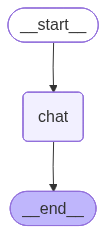

In [10]:
app

In [29]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [30]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='563f0e55-4ee8-47d3-bdbb-011a43c523f3'),
  AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='ed51840f-9cff-44d9-b168-b7035825d7c7'),
  HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='f81f085e-ace0-49c4-8957-68a17333d620'),
  AIMessage(content='**Gradient descent** is a way for a computer (or a mathematician) to find the lowest point on a bumpy surface—think of it like finding the bottom of a valley in a hilly landscape. Here’s a super‑simple way to picture it:\n\n1. **Imagine a hill**  \n   - The height of the hill at any spot represents how “bad” a particular solution is. Lower height = better solution.\n\n2. **Start somewhere**  \n   - You pick a random spot on the hill (a random guess for the solution).\n\n3. **Feel which way is downhill**  \n   - At 

In [31]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [32]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [33]:
## resume the graph based on user input

final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config
)

In [35]:
print(final_result["messages"][-1].content)

**Gradient descent** is just a way to “slide downhill” to find the best answer.

1. **Picture a hill** – The height of the hill tells you how *bad* a solution is. Lower height = better solution (less error).

2. **Pick a starting spot** – You start at a random point on the hill (a random guess for the model’s parameters).

3. **Feel the slope** – At that spot you check which direction goes down the steepest. In math this direction is called the **gradient** (the slope).

4. **Take a small step** – Move a little bit in that downhill direction. How big the step is is the **learning rate**.

5. **Repeat** – Keep checking the slope, stepping downhill, and checking again. Each step should bring you closer to the bottom.

6. **Stop when it’s flat** – When the slope is almost zero (the hill is flat) you’re near the lowest point, so you stop.

---

### Why it matters for machine learning
The “hill” is the model’s error (loss). Gradient descent automatically adjusts the model’s parameters so th